In [8]:
import pandas as pd

In [9]:
df=pd.read_csv(r'D:\nlp\data_for_preprocessing.csv')

In [10]:
df

,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human
...,...,...,...
6064,6064,Computational models serve as useful compleme...,Human
6065,6065,During transport and storage of drinking wate...,Human
6066,6066,The parameter values of neural networks will ...,Human
6067,6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human


In [11]:
# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [13]:
df = df.drop(columns=["Unnamed: 0"])

df["Author"] = df["Author"].map({
    "Human":0,
    "AI":1
})


In [14]:
print(df['Author'].value_counts())

Author
1    3069
0    3000
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split

X = df['Text']
y = df['Author']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000
max_len = 200

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [31]:
model = models.Sequential([

   layers.Embedding(10000, 64, input_length=max_len),
  

   layers.LSTM(64),
  

   layers.Dense(32, activation='relu'),

   layers.Dense(1, activation='sigmoid') 
  
])


d:\Saran\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [33]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 0.9086 - loss: 0.2106 - val_accuracy: 0.9990 - val_loss: 0.0121
Epoch 2/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - accuracy: 0.9969 - loss: 0.0141 - val_accuracy: 0.9990 - val_loss: 0.0072
Epoch 3/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.9985 - loss: 0.0071 - val_accuracy: 0.9990 - val_loss: 0.0091
Epoch 4/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.9995 - loss: 0.0032 - val_accuracy: 0.9979 - val_loss: 0.0096
Epoch 5/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9979 - val_loss: 0.0082


In [34]:
loss, accuracy = model.evaluate( X_test_pad, y_test)

print("Accuracy:", accuracy)



38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9975 - loss: 0.0051
Accuracy: 0.9975288510322571


In [35]:
text = ["constraining Grand Unified Theories"]

seq = tokenizer.texts_to_sequences(text)
pad = pad_sequences(seq, maxlen=100)

prediction = model.predict(pad)

if prediction > 0.5:
   print("Human")
else:
   print("AI")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
Human


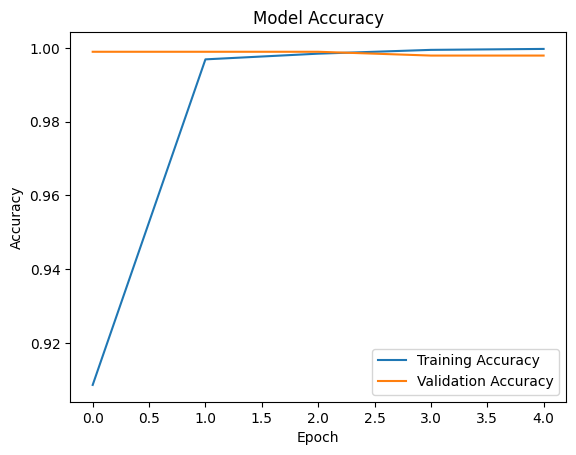

In [36]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [37]:
from collections import Counter

word_counts = Counter()

for text in df["Text"]:
    words = text.lower().split()
    word_counts.update(words)

vocab_size = 5000
vocab = word_counts.most_common(vocab_size)

word_index = {word: i+3 for i,(word,count) in enumerate(vocab)}

word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2

In [38]:
def encode_review(text):

    words = text.lower().split()

    encoded = []

    for word in words:
        encoded.append(word_index.get(word, 2))  # unknown = 2

    return encoded

In [39]:
encoded_texts = []

for text in df["Text"]:
    encoded_texts.append(encode_review(text))

In [40]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200

X = pad_sequences(encoded_texts, maxlen=max_len, padding="post")
y = df["Author"]

In [43]:
review = "This study investigates the chemical composition of thermal springs in Afyonkarahisar, assessing their potential for health tourism"
encoded = encode_review(review)

padded = pad_sequences([encoded], maxlen=200)

prediction = model.predict(padded)

print("Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("AI Generated")
else:
    print("Human Written")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Score: 0.9947532
AI Generated
